Pre-processing the dataset:

In [97]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

DATASET_PATH = "../datasets"
df = pd.read_csv(f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv")

# todo: recency score - figure out a good balance
df["recency_score"] = 1 / ((time.time() - df["mod_time_unix"]) / (90 * 24 * 3600) + 1)
df["size_logged"] = np.log1p(df["size_bytes"])
df["name_len"] = df["filename"].apply(len)
df["path_len"] = df["path"].apply(len)
df["path_depth"] = df["path"].apply(lambda p: p.count("/") + p.count("\\"))

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(4, 4),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

# # Dropping original columns after they've been used for feature creation
# df.drop(
#     ["filename", "path", "extension", "size_bytes", "mod_time_unix"],
#     axis=1,
#     inplace=True,
# )

df

,filename,path,extension,size_bytes,mod_time_unix,source_user,source_type,label_finance,label_hr,label_it,label_general,recency_score,size_logged,name_len,path_len,path_depth
0,input-v5.js,\\wsl$\Ubuntu\home\ashleywagner\projects\acf-t...,.js,26869,1.725281e+09,ashleywagner,github_real,0,0,0,0,0.155884,10.198766,11,99,11
1,Resume.docx,C:\Users\jason47\Documents\HR\Talent_Acquisiti...,.docx,41943,1.697627e+09,jason47,govdoc_real,0,1,0,1,0.100287,10.644091,11,64,7
2,local_settings.py,C:\Users\ariel00\Dev\tvm-1,.py,3273,1.713868e+09,dev_injector,secret_injection,0,0,1,1,0.126859,8.093768,17,26,4
3,JcjUutrEIIH0RTqlMwlbHVdn1p_lQ_b5_ZrV_seatE64oR...,C:\Users\zphillips\OneDrive - Corp\Backup,.txt,31996,1.750231e+09,synthetic_noise,long_name_injector,0,0,0,0,0.311874,10.373397,183,41,4
4,2441a-cvr.pdf,Z:\HR\Recruiting\Reqs\2023,.pdf,3628072,1.464273e+09,deanna44,govdoc_real,0,0,0,0,0.025012,15.104212,13,26,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993,KB956803.CAT,C:\Windows\$hf_mig$\KB956803\update,.cat,12431,1.691768e+09,jo,system_noise,0,0,0,0,0.093241,9.428029,12,35,4
2994,2DOPIN_1.docx,C:\Users\benjamin08\Documents\Drafts\Docx,.docx,20971,1.436033e+09,benjamin08,govdoc_real,0,0,0,0,0.022929,9.950943,13,41,5
2995,clear_water_lg.docx,C:\Users\patriciamiranda\Documents\Drafts\Docx,.docx,146800,1.607601e+09,patriciamiranda,govdoc_real,0,0,0,0,0.046406,11.896833,19,46,5
2996,test_ssd1306.py,D:\Archive\Legacy_Projects\gfxlcd\gfxlcd\tests,.py,464,1.721887e+09,backup_svc,github_real,0,0,0,0,0.145954,6.142037,15,46,5


Training:

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define target-specific valuable extensions
target_extension_map = {
    "label_finance": [".xlsx", ".xls", ".csv", ".pdf", ".accp", ".pptx"],
    "label_hr": [".docx", ".doc", ".rtf", ".pdf", ".xlsx", ".xls"],
    "label_it": [
        ".pem",
        ".key",
        ".kdbx",
        ".p12",
        ".ovpn",
        ".private",
        ".wallet",
        ".sql",
        ".env",
    ],
}

# Add "label_general" after defining the other labels
target_extension_map["label_general"] = list(
    set(
        target_extension_map["label_finance"]
        + target_extension_map["label_hr"]
        + target_extension_map["label_it"]
    )
)
common_dev_junk = [
    ".pyc",
    ".pyi",
    ".lcl",
    ".pyd",
    ".map",
    ".ts",
    ".js",
    ".spec",
    ".test.js",
]

# Define target-specific junk extensions
target_junk_map = {
    "label_finance": [".class", ".java", ".cpp", ".obj", ".dll", ".exe"]
    + common_dev_junk,
    "label_hr": [".class", ".java", ".py", ".obj", ".dll", ".exe"] + common_dev_junk,
    "label_it": [".tmp", ".log", ".cache"]
    + [ext for ext in common_dev_junk if ext not in [".ts", ".js"]],
}

target_junk_map["label_general"] = list(
    set(
        target_junk_map["label_finance"]
        + target_junk_map["label_hr"]
        + target_junk_map["label_it"]
    )
)


models_map = {}

for target in {"label_general", "label_it", "label_finance", "label_hr"}:

    # Prepare Data
    df_temp = df.copy()
    df_temp["valuable_ext"] = df_temp["extension"].isin(target_extension_map[target]).astype(int)
    df_temp["junk_ext"] = df_temp["extension"].isin(target_junk_map[target]).astype(int)

    df_temp.to_csv("1.csv", index=False)

    # Create feature matrix X and target vector y for the current target
    numerical_features = df_temp[
        [
            "recency_score",
            "size_logged",
            "valuable_ext",
            "junk_ext",
            "name_len",
            "path_len",
            "path_depth",
        ]
    ].values
    X_target = hstack([numerical_features, filename_vectors, path_vectors])
    y_target = df_temp[target].values

    # Split Data
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_target, y_target, df_temp.index, test_size=0.2, random_state=42, stratify=y_target
    )

    # Train Model
    model = LogisticRegression(solver="lbfgs", max_iter=1000, C=0.5, class_weight="balanced")
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]

    print("Accuracy for", target, ":", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    models_map[target] = model

Accuracy for label_general : 0.915

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94       464
           1       0.81      0.82      0.81       136

    accuracy                           0.92       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.92      0.92      0.92       600

Accuracy for label_it : 0.9716666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       508
           1       0.89      0.93      0.91        92

    accuracy                           0.97       600
   macro avg       0.94      0.96      0.95       600
weighted avg       0.97      0.97      0.97       600

Accuracy for label_hr : 0.9566666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       574
           1       0.50      0.54      0.

Top results for model targeting label_general:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
158,client_secret.json,C:\Users\butlerpeter\Dev\SoftUniProject,.json,2383,18,39,4,1.704317e+09,1,0.996609
279,id_dsa,C:\Users\freemanjessica\Downloads\test-java-ma...,NaN,14773,6,122,13,1.710239e+09,1,0.990977
367,wp-config.php,C:\Users\lbaker\Desktop\Coding\config,.php,3522,13,37,5,1.731887e+09,1,0.990140
471,db.sqlite3,C:\Users\lucasgomez\Desktop\Code_Review\elasti...,.sqlite3,112639,10,95,12,1.713118e+09,1,0.989726
579,secrets.py,C:\Users\mitchellveronica\Desktop\Coding\config,.py,2554,10,47,5,1.705541e+09,1,0.987250
197,.env.production,C:\Users\vramirez\Dev\ResInsight,.production,2144,15,32,4,1.701633e+09,1,0.985460
396,database.json,C:\Users\tharrison\AppData\Local,.json,3284,13,32,4,1.714667e+09,1,0.985070
75,app.config,C:\Users\rachelbennett\Desktop\Coding,.config,2103,10,37,4,1.702168e+09,1,0.984835
260,client_secret.json,C:\Temp\Publish\morpheus-cli\lib,.json,3880,18,32,4,1.690069e+09,1,0.979272
238,.env.production,C:\Users\jacksonchad\source\repos\config,.production,2490,15,40,5,1.690864e+09,1,0.978825


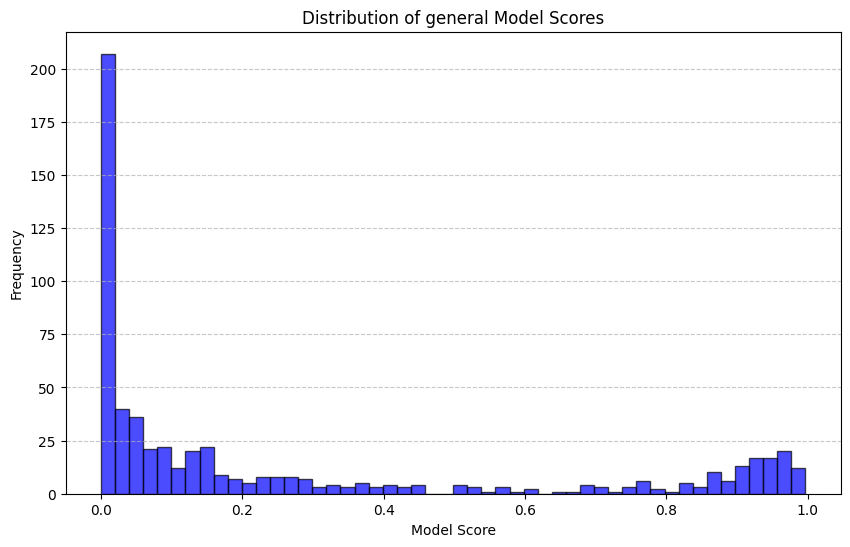

Top results for model targeting label_it:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
408,secrets.json,C:\Users\robertluna\Downloads\mtucicoin-master,.json,813,12,46,4,1.727230e+09,1,0.991340
158,client_secret.json,C:\Users\butlerpeter\Dev\SoftUniProject,.json,2383,18,39,4,1.704317e+09,1,0.991218
579,secrets.py,C:\Users\mitchellveronica\Desktop\Coding\config,.py,2554,10,47,5,1.705541e+09,1,0.990013
396,database.json,C:\Users\tharrison\AppData\Local,.json,3284,13,32,4,1.714667e+09,1,0.989962
497,database.json,C:\Apps\Production\ingress\internal\config,.json,2557,13,42,5,1.731329e+09,1,0.986865
335,.env,C:\Users\barbarajones\AppData\Local\config,.env,888,4,42,5,1.704119e+09,1,0.986622
216,.env,C:\Users\qrocha\Desktop\Coding,.env,3807,4,30,4,1.722656e+09,1,0.986126
279,id_dsa,C:\Users\freemanjessica\Downloads\test-java-ma...,NaN,14773,6,122,13,1.710239e+09,1,0.985757
367,wp-config.php,C:\Users\lbaker\Desktop\Coding\config,.php,3522,13,37,5,1.731887e+09,1,0.985687
306,config.yml,C:\Users\gary29\Desktop\Coding,.yml,1626,10,30,4,1.710113e+09,1,0.985195


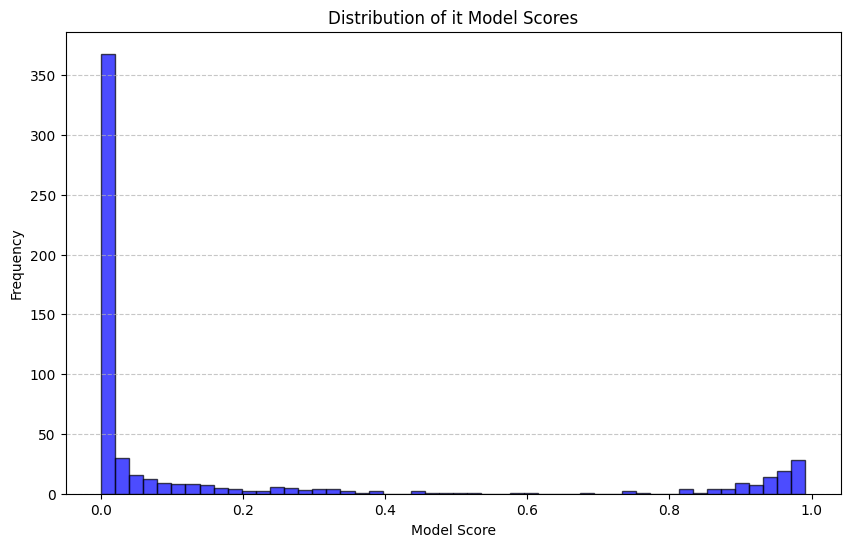

Top results for model targeting label_hr:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
302,6.EmployeesHiredAfter.sql,C:\Users\john02\AppData\Local\Packages\Canonic...,.sql,243,25,160,13,1.681547e+09,1,0.993126
97,CWE78_OS_Command_Injection__char_connect_socke...,C:\Work\Projects\tiamat\samples\Juliet\testcas...,.c,6320,62,79,8,1.676008e+09,1,0.980323
163,TABLE 2.6 Screen_Lower Vadose rev3.docx,Z:\HR\Recruiting\Reqs\2024\Lower,.docx,20971,39,32,5,1.678799e+09,1,0.966224
330,3-06cv00065 Silver Ring v Digisplint _granting...,Z:\HR\Recruiting\Reqs\2023,.docx,83886,65,26,4,1.680885e+09,1,0.963004
366,2025 CV Local Rules.docx,Z:\HR\Recruiting\Reqs\2024,.docx,314572,24,26,4,1.707330e+09,1,0.962211
499,CWE78_OS_Command_Injection__char_console_w32_e...,C:\Users\sheilacampbell\Desktop\Coding\tiamat\...,.cpp,2302,58,101,10,1.677107e+09,1,0.961759
429,DfE General Screen for Safer Ingredients 2.3.0...,Z:\HR\Recruiting\Reqs\2023\Screen,.doc,157286,51,33,5,1.706780e+09,1,0.955026
0,Resume 2008b.docx,Z:\HR\Recruiting\Reqs\2023,.docx,157286,17,26,4,1.702483e+09,1,0.941513
33,2025 CV Local Rules.docx,Z:\HR\Recruiting\Reqs\2025\Rules,.docx,188743,24,32,5,1.707330e+09,1,0.938856
424,FeatBonus.cs,C:\Users\tony72\source\repos\pfsolution\pre\sr...,.cs,91,12,78,11,1.731415e+09,1,0.925871


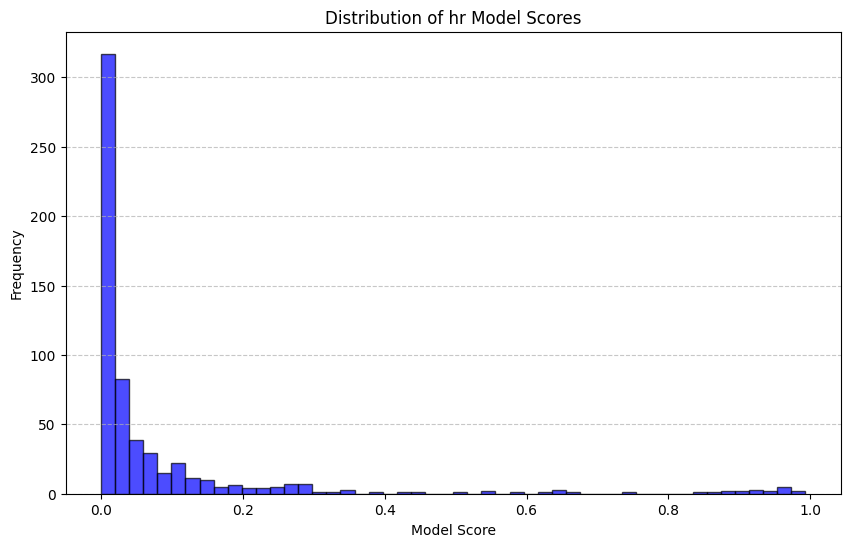

Top results for model targeting label_finance:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
540,Invoice.java,C:\Users\hsmith\Desktop\Coding\Invoice_generat...,.java,655,12,64,8,1.691554e+09,1,0.968356
64,RD Budget 23 pager_FINAL.docx,Z:\Finance\General_Ledger\2024,.docx,587202,29,30,3,1.688848e+09,1,0.959044
459,SaveBudgetPeriodRule.java,C:\inetpub\wwwroot\kc.preclean\coeus-code\src\...,.java,1082,25,102,14,1.676201e+09,1,0.953611
336,Malaria Comparison chart v4 (1).pdf,Z:\HR\Payroll\Cycles\2024,.pdf,20971,35,25,4,1.701506e+09,1,0.946035
344,InvoiceStatementBatchListWrapper.java,C:\Users\moorechristopher\Desktop\Coding\sdk-r...,.java,441,37,104,14,1.676360e+09,1,0.940190
382,Pods-ForecastIO iOS Tests-frameworks.sh,C:\Users\kmorris\Desktop\Coding\ForecastIO\Pod...,.sh,8050,39,94,8,1.731118e+09,1,0.908262
72,NCAI Testimony-SCIA re FY25 Budget FINAL2.docx,Z:\Finance\General_Ledger\2023\Budget,.docx,356515,46,37,4,1.596102e+09,0,0.892415
222,budgetsummary.rtf,C:\Users\zberger\OneDrive - Corp\Finance\Repor...,.rtf,272629,17,50,5,1.517501e+09,0,0.884675
27,SalesInvoicePost.cs,C:\Work\Projects\moneysharp\src\MoneySharp\Int...,.cs,322,19,57,7,1.691040e+09,1,0.880071
521,BudgetInBrief.docx,C:\Users\heatherjones\OneDrive - Corp\Finance\...,.docx,62914,18,69,6,1.710186e+09,1,0.875786


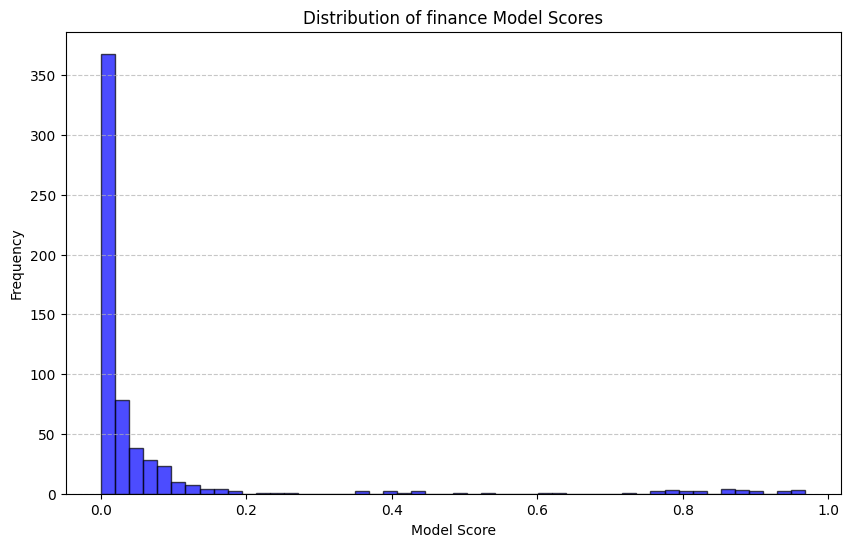

In [111]:
import matplotlib.pyplot as plt

for target, model in models_map.items():
    print(f"Top results for model targeting {target}:")

    # Get test set predictions
    y_test = df.loc[idx_test][target].values
    y_scores = model.predict_proba(X_test)[:, 1]

    results = pd.DataFrame(
        {
            "filename": df.loc[idx_test]["filename"].values,
            "filepath": df.loc[idx_test]["path"].values,
            "extension": df.loc[idx_test]["extension"].values,
            "size_bytes": df.loc[idx_test]["size_bytes"].values,
            "name_len": df.loc[idx_test]["name_len"].values,
            "path_len": df.loc[idx_test]["path_len"].values,
            "path_depth": df.loc[idx_test]["path_depth"].values,
            "mod_time_unix": df.loc[idx_test]["mod_time_unix"].values,
            "actual_label": y_test,
            "model_score": y_scores,
        }
    )

    # Sort and slice the results
    sorted_results = results.sort_values(by="model_score", ascending=False)
    display(sorted_results[:10])

    # Plot the distribution of model scores
    plt.figure(figsize=(10, 6))
    plt.hist(
        results["model_score"], bins=50, color="blue", alpha=0.7, edgecolor="black"
    )
    plt.title(f"Distribution of {target.split("_")[1]} Model Scores")
    plt.xlabel("Model Score")
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

Exporting weights:

In [112]:
import os

output_path = f"../include/ModelWeights.h"

# 3. Ensure Directory Exists and Write
os.makedirs(os.path.dirname(output_path), exist_ok=True)

cpp_content = f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 

#include <vector>
#include <unordered_set>
#include <string>
# """

for target, model in models_map.items():

    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()
    title = target.split("_")[1].upper()
    cpp_content += f"""
const double {title}_MODEL_BIAS = {bias:.10f};

// recency score - size_logged - valuable_ext -  junk_ext - name_len - path_len - path_depth - filename features(1024) - path features(1024)
const std::vector<double> {title}_MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> {title}_HIGH_VAL_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_extension_map[target]])}}};

const std::unordered_set<std::wstring> {title}_JUNK_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_junk_map[target]])}}};
"""

with open(output_path, "w") as f:
    f.write(cpp_content)